###Env to use: birdnet

In [14]:
import librosa
from skimage import feature
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import soundfile as sf
import os
from pathlib import Path
from sklearn.metrics import average_precision_score, accuracy_score


In [2]:
import inspect
from birdnetlib.analyzer import Analyzer
print(inspect.signature(Analyzer))

c:\Users\dgnhk\anaconda3\envs\birdnet\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)



(custom_species_list_path=None, custom_species_list=None, classifier_model_path=None, classifier_labels_path=None, version=None)


In [3]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer
from datetime import datetime

# Load and initialize the BirdNET-Analyzer models.
analyzer = Analyzer(
    classifier_model_path="../models/BirdNET-Analyzer-V2.2/V2.2/BirdNET_GLOBAL_3K_V2.2_Model_FP32.tflite",
    classifier_labels_path="../models/BirdNET-Analyzer-V2.2/V2.2/BirdNET_GLOBAL_3K_V2.2_Labels.txt"
)

load_custom_models
Custom model loaded.
loading custom classifier labels
Labels loaded.
load model False
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.


Predict for positive segments first

In [4]:
output_folder='../data/test_data/audio/1/'
wav_files = os.listdir(output_folder)

In [5]:
predictions = dict.fromkeys(wav_files, 0.0)

In [6]:
for file in wav_files:
    audio_path = Path(os.path.join(output_folder, file))
    recording = Recording(
        analyzer,
        audio_path,
        min_conf=0.0
    )
    recording.analyze()
    for detection in recording.detections:
        if detection['scientific_name']=='Scolopax rusticola':
            predictions[file] = detection['confidence']

read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_0.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_12.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_15.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_18.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_21.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_24.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_27.wav
read_audio_data
read_audio_data: complete, read  1 chunk

In [7]:
np.mean(list(predictions.values()))

0.6845644789897761

Predict for negative segments

In [8]:
output_folder='../data/test_data/audio/0/'
wav_files = os.listdir(output_folder)

In [9]:
predictions.update(dict.fromkeys(wav_files, 0.0))

In [10]:
for file in wav_files:
    audio_path = Path(os.path.join(output_folder, file))
    recording = Recording(
        analyzer,
        audio_path,
        min_conf=0.0
    )
    recording.analyze()
    for detection in recording.detections:
        if detection['scientific_name']=='Scolopax rusticola':
            predictions[file] = detection['confidence']

read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1009958 - Eurasian Woodcock - Scolopax rusticola_9.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1032841 - Eurasian Woodcock - Scolopax rusticola_0.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1032846 - Eurasian Woodcock - Scolopax rusticola_27.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1032847 - Eurasian Woodcock - Scolopax rusticola_0.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1032847 - Eurasian Woodcock - Scolopax rusticola_3.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1032847 - Eurasian Woodcock - Scolopax rusticola_6.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
analyze_recording XC1035339 - Eurasian Woodcock - Scolopax rusticola_0.wav
read_audio_data
read_audio_data: complete, read  1 chunks.
an

In [11]:
np.save('testset1_predictions.npy', predictions)

In [20]:
sorted_keys = sorted(predictions.keys())

# Step 2: Extract scores and generate true labels
y_pred = [predictions[k] for k in sorted_keys]
y_true = [1 if "Woodcock" in k else 0 for k in sorted_keys]

# Step 3: Compute Average Precision
ap = average_precision_score(y_true, y_pred)
ap

1.0

In [24]:
for k in sorted_keys[:20]:
    print(k)

XC1009958 - Eurasian Woodcock - Scolopax rusticola_0.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_12.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_15.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_18.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_21.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_24.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_27.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_3.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_30.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_33.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_36.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_39.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_6.wav
XC1009958 - Eurasian Woodcock - Scolopax rusticola_9.wav
XC1032841 - Eurasian Woodcock - Scolopax rusticola_0.wav
XC1032841 - Eurasian Woodcock - Scolopax rusticola_12.wav
XC1032841 - Eurasian Woodcock - Scolopax rusticola_15.wav
XC1032841 - Eurasia

In [21]:
# Convert scores to binary predictions
threshold = 0.4
y_pred_binary = [1 if p >= threshold else 0 for p in y_pred]

# Accuracy
acc = accuracy_score(y_true, y_pred_binary)

print(f"AP: {ap:.4f}")
print(f"Accuracy: {acc:.4f}")

AP: 1.0000
Accuracy: 0.5502


In [22]:
pos = np.array(y_pred)[np.array(y_true) == 1]
neg = np.array(y_pred)[np.array(y_true) == 0]

print("Positive range:", pos.min(), pos.max())
print("Negative range:", neg.min(), neg.max())

Positive range: 0.0 0.9999909400939941


ValueError: zero-size array to reduction operation minimum which has no identity

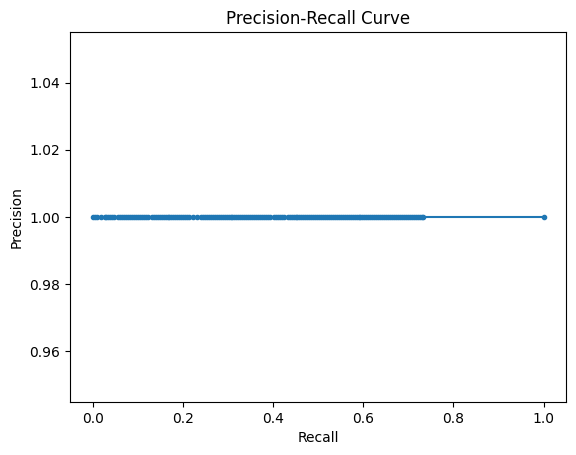

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Only for binary classification (adjust for multi-class)
precision, recall, thr = precision_recall_curve(y_true, y_pred)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


Text(0.5, 0, 'Threshold')

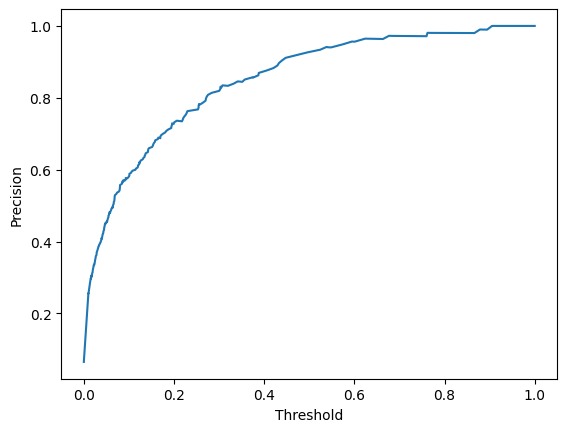

In [ ]:
plt.plot(thr,precision[:-1])
plt.ylabel("Precision")
plt.xlabel("Threshold")

Text(0.5, 0, 'Threshold')

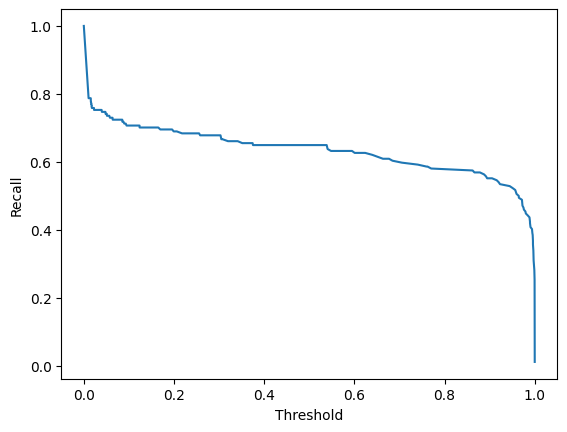

In [ ]:
plt.plot(thr, recall[:-1])
plt.ylabel("Recall")
plt.xlabel("Threshold")

In [ ]:
#preds_negative = {k: predictions[k] for k in wav_files if k in predictions}
#preds_negative = np.array(list(preds_negative.values()))

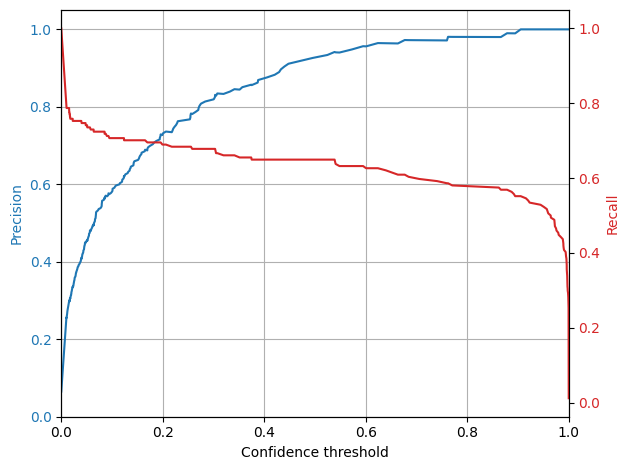

In [ ]:


# Sample data
x = thr
y1 = precision[:-1]            # First curve
y2 = recall[:-1]      # Second curve

# Create figure and first axis
fig, ax1 = plt.subplots()

# Plot the first line
color1 = 'tab:blue'
ax1.set_xlabel('Confidence threshold')
ax1.set_ylabel('Precision', color=color1)
ax1.plot(x, y1, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True) 
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Recall', color=color2)
ax2.plot(x, y2, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Optional: improve layout
fig.tight_layout()

plt.show()


In [ ]:
f1 = 2*precision*recall/(precision+recall)
np.max(f1)

0.7687074829931972

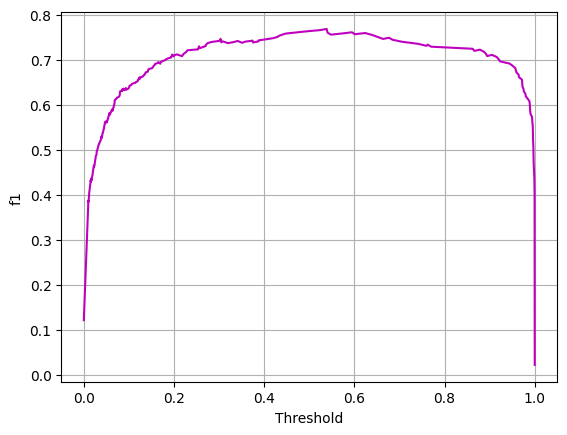

In [ ]:
plt.plot(thr, f1[:-1], '-m')
plt.ylabel("f1")
plt.xlabel("Threshold")
plt.grid()

In [ ]:
from scipy.interpolate import interp1d

thr_uniform = np.linspace(thr.min(), thr.max(), 100)
interpolator = interp1d(thr, f1[:-1], kind='linear')  # or 'cubic', 'quadratic', etc.
f1_score = interpolator(thr_uniform)

In [ ]:
np.savez('testset1_f1.npz', thr=thr_uniform, f1=f1_score)

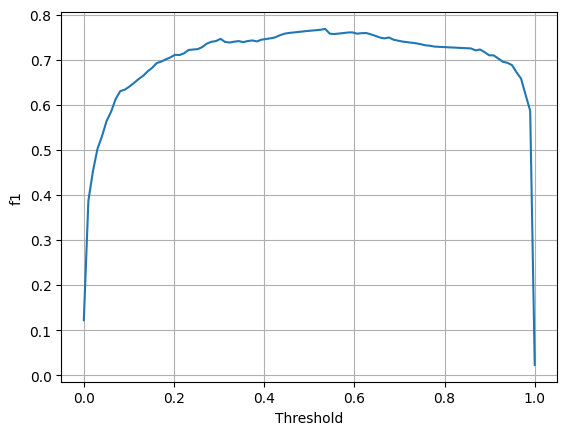

In [ ]:
plt.plot(thr_uniform,f1_score)
plt.ylabel("f1")
plt.xlabel("Threshold")
plt.grid()